<a href="https://colab.research.google.com/github/ssalazaro94/IMU-analizer/blob/main/Codigo_analisis_marcha_con_IMU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

datos_marcha = pd.read_csv("/content/Xsens DOT3_D422CD007B02_20260226_154606.csv")

datos_marcha.head()

,PacketCounter,SampleTimeFine,Quat_W,Quat_X,Quat_Y,Quat_Z,Acc_X,Acc_Y,Acc_Z,Gyr_X,Gyr_Y,Gyr_Z,Unnamed: 12
0,0,811998985,0.348415,0.572963,-0.473057,0.571437,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,
1,1,812015652,0.348201,0.573124,-0.472903,0.571535,9.914825,-1.495361,-1.088996,0.387667,-0.249877,2.925412,
2,2,812032319,0.347982,0.573316,-0.472674,0.571665,9.918355,-1.468314,-1.086285,0.716989,-0.057417,2.635188,
3,3,812048986,0.347791,0.573493,-0.472428,0.571805,9.907597,-1.469166,-1.064551,0.941260,0.131950,2.510461,
4,4,812065653,0.347559,0.573704,-0.472143,0.571971,9.894433,-1.451123,-1.053972,1.240718,0.086225,2.485546,


In [ ]:
import numpy as np

#  Se escala el tiempo con una frecuencia de muestreo de 60 hz, es decir, toma una muestra cada 0,016667 segundos (aqui iniciara)

intervalo_muestreo = 0.016667  # segundos

# Crea una nueva columna «tiempo_segundos» que comience en 0,016667 con el «intervalo_muestra» calculado
datos_marcha['tiempo_segundos'] = np.arange(intervalo_muestreo, (len(datos_marcha) + 1) * intervalo_muestreo, intervalo_muestreo)

# Muestra la parte inicial del DataFrem con la nueva columna
display(datos_marcha.head())

,PacketCounter,SampleTimeFine,Quat_W,Quat_X,Quat_Y,Quat_Z,Acc_X,Acc_Y,Acc_Z,Gyr_X,Gyr_Y,Gyr_Z,Unnamed: 12,tiempo_segundos
0,0,811998985,0.348415,0.572963,-0.473057,0.571437,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,,0.016667
1,1,812015652,0.348201,0.573124,-0.472903,0.571535,9.914825,-1.495361,-1.088996,0.387667,-0.249877,2.925412,,0.033334
2,2,812032319,0.347982,0.573316,-0.472674,0.571665,9.918355,-1.468314,-1.086285,0.716989,-0.057417,2.635188,,0.050001
3,3,812048986,0.347791,0.573493,-0.472428,0.571805,9.907597,-1.469166,-1.064551,0.941260,0.131950,2.510461,,0.066668
4,4,812065653,0.347559,0.573704,-0.472143,0.571971,9.894433,-1.451123,-1.053972,1.240718,0.086225,2.485546,,0.083335


In [ ]:
# muestra el nombre de las columnas que tiene el DataFrem
datos_marcha.columns

Index(['PacketCounter', 'SampleTimeFine', 'Quat_W', 'Quat_X', 'Quat_Y',
       'Quat_Z', 'Acc_X', 'Acc_Y', 'Acc_Z', 'Gyr_X', 'Gyr_Y', 'Gyr_Z',
       'Unnamed: 12', 'tiempo_segundos'],
      dtype='object')

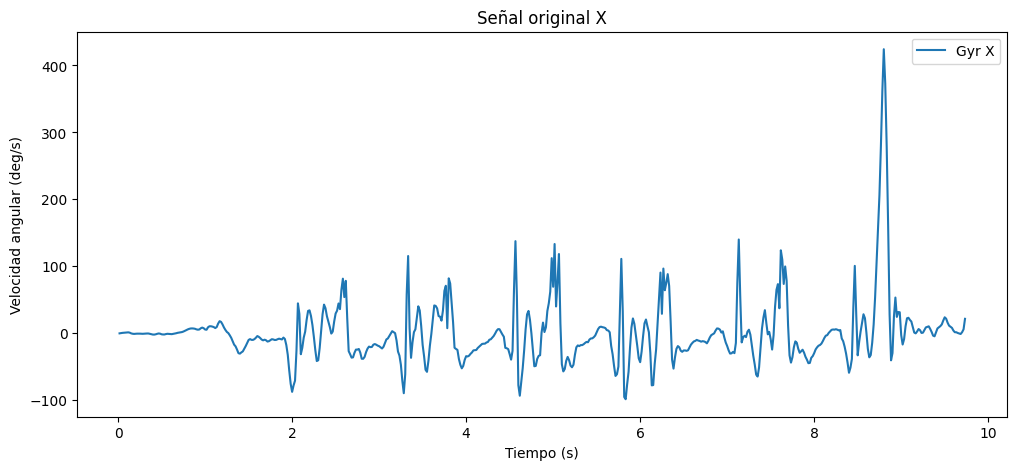

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(datos_marcha['tiempo_segundos'], datos_marcha['Gyr_X'], label='Gyr X')

plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad angular (deg/s)')
plt.title('Señal original X')

plt.legend()
plt.show()

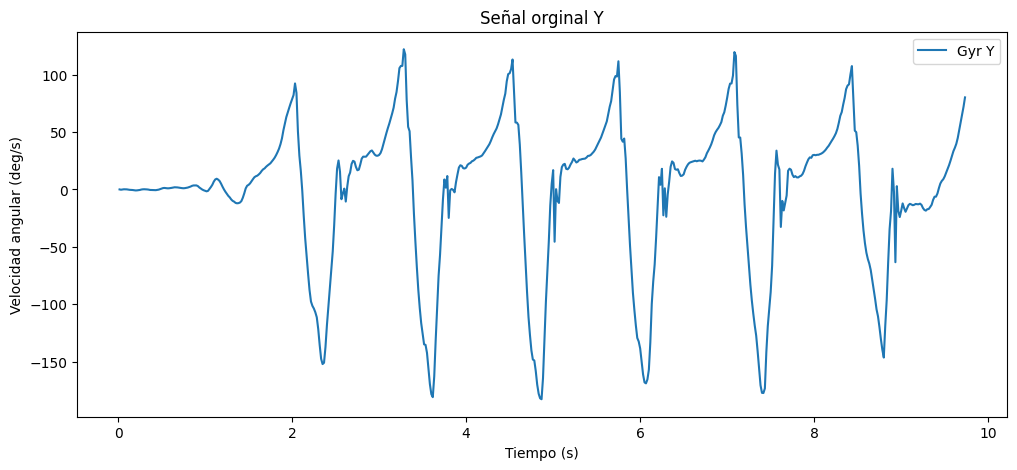

In [ ]:

plt.figure(figsize=(12,5))

plt.plot(datos_marcha['tiempo_segundos'], datos_marcha['Gyr_Y'], label='Gyr Y')

plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad angular (deg/s)')
plt.title('Señal orginal Y')

plt.legend()
plt.show()

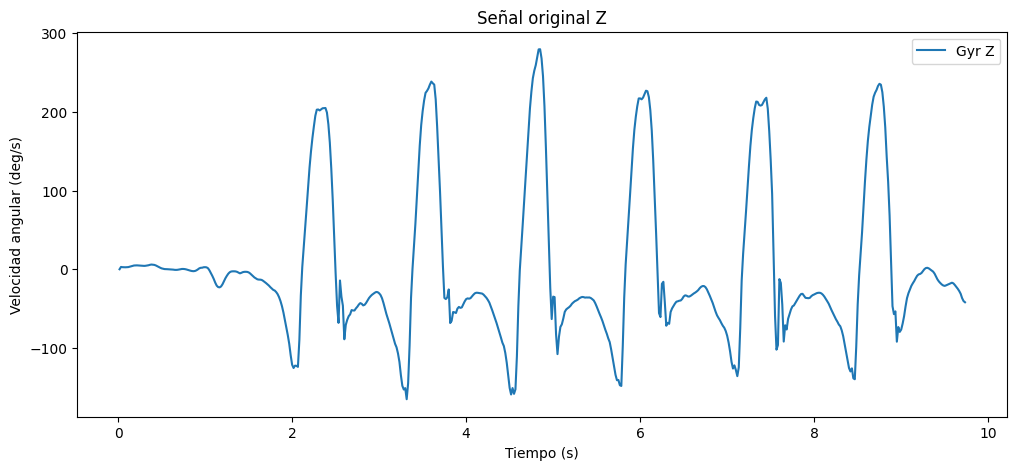

In [ ]:

plt.figure(figsize=(12,5))

plt.plot(datos_marcha['tiempo_segundos'], datos_marcha['Gyr_Z'], label='Gyr Z')

plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad angular (deg/s)')
plt.title('Señal original Z')

plt.legend()
plt.show()

In [ ]:
def filtro_pasa_altas(senal, alpha=0.995):
    senal_filtrada = np.zeros_like(senal)

    for i in range(1, len(senal)):
        senal_filtrada[i] = senal[i] - senal[i-1] + alpha * senal_filtrada[i-1]

    return senal_filtrada

In [ ]:
senal_velocidad_angular = datos_marcha['Gyr_Z'].values

# forward
senal_filtrada_adelante = filtro_pasa_altas(senal_velocidad_angular)

# backward
senal_invertida= senal_filtrada_adelante[::-1]

# invertir otra vez
senal_filtrada_atras = filtro_pasa_altas(senal_invertida)

senal_filtrada = senal_filtrada_atras[::-1]

datos_marcha['Gyr_Z_filt'] = senal_filtrada

In [ ]:
datos_marcha['Gyr_Z_filt'] = -datos_marcha['Gyr_Z_filt']

In [ ]:
datos_marcha['Gyr_Z_original_inv'] = -datos_marcha['Gyr_Z']

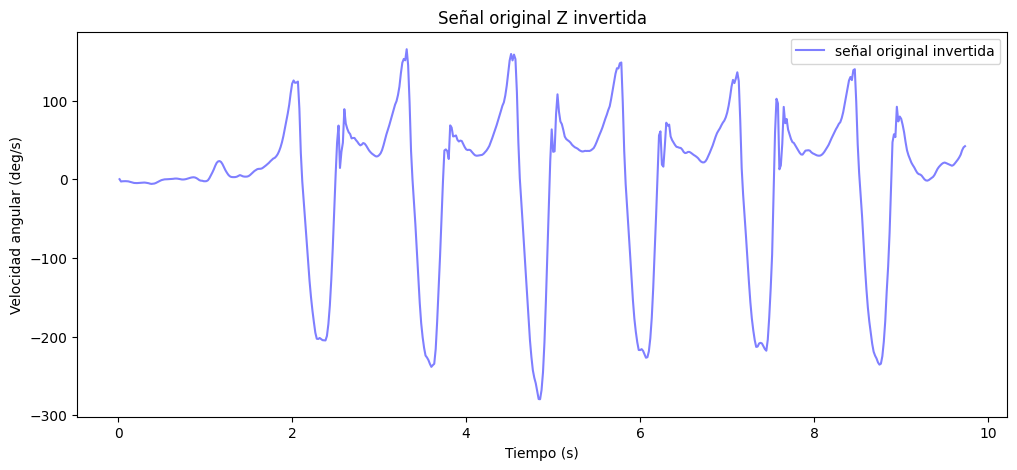

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(datos_marcha['tiempo_segundos'], datos_marcha['Gyr_Z_original_inv'], label='señal original invertida', alpha=0.5, color='blue')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad angular (deg/s)')
plt.title('Señal original Z invertida')

plt.legend()
plt.show()

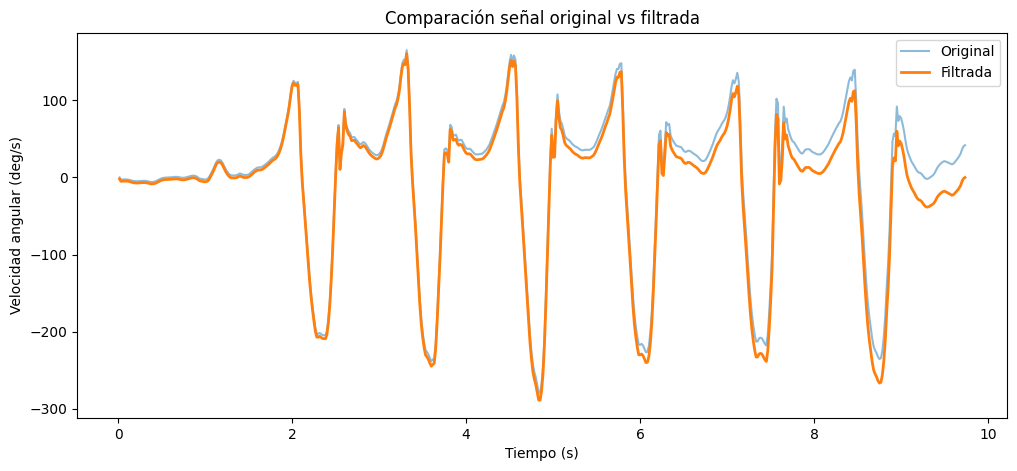

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(datos_marcha['tiempo_segundos'], datos_marcha['Gyr_Z_original_inv'], label='Original', alpha=0.5)
plt.plot(datos_marcha['tiempo_segundos'], datos_marcha['Gyr_Z_filt'], label='Filtrada', linewidth=2)

plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad angular (deg/s)')
plt.title('Comparación señal original vs filtrada')

plt.legend()
plt.show()

In [ ]:
senal_velocidad_angular = datos_marcha['Gyr_Z_filt'].values.copy()   # Señal filtrada

# Ajustar automáticamente el sentido del eje Z
if abs(np.min(senal_velocidad_angular)) > abs(np.max(senal_velocidad_angular)):
    senal_velocidad_angular = -senal_velocidad_angular

tiempo_sensor = datos_marcha['SampleTimeFine'].values
frecuencia_muestreo = 1 / (tiempo_sensor[1] - tiempo_sensor[0])

In [ ]:
tiempo_segundos = datos_marcha ['SampleTimeFine'].values / 1_000_000  # Convierte de microsegundos a segundos
frecuencia_muestreo_convertida = 1 / (tiempo_segundos [1] - tiempo_segundos[0])

from scipy.signal import find_peaks

# umbral según Articulo (~50 deg/s)
picos_balanceo, propiedades = find_peaks(senal_velocidad_angular, height=50, distance=int(0.5*frecuencia_muestreo_convertida))

balanceo_medio = picos_balanceo

In [ ]:
from scipy.signal import find_peaks

contacto_inicial_pie = []
contacto_terminal_pie = []

# detectar mínimos locales en toda la señal
minimos_locales, _ = find_peaks(-senal_velocidad_angular, distance=int(0.3*frecuencia_muestreo_convertida))

for ms in balanceo_medio:

    # mínimos antes del tiempo de balanceo
    minimos_antes = minimos_locales[minimos_locales < ms]

    # mínimos después del tiempo de balanceo
    minimos_despues = minimos_locales[minimos_locales > ms]

    # detección del contacto terminal (antes del tiempo balanceo)
    if len(minimos_antes) > 0:
        tc = minimos_antes[-1]  # el más cercano antes

        if senal_velocidad_angular[tc] < -20:  # umbral del Articulo
            contacto_terminal_pie.append(tc)

    # contacto incial (después del balanceo)
    if len(minimos_despues) > 0:
        ic = minimos_despues[0]  # el más cercano después
        contacto_inicial_pie.append(ic)

In [ ]:
print("cantidad puntos de balanceo:", len(balanceo_medio))
print("Cantidad de mínimos:", len(minimos_locales))
print("cantidad de IC", len(contacto_inicial_pie))
print("Cantidad de TC:", len(contacto_terminal_pie))

cantidad puntos de balanceo: 6
Cantidad de mínimos: 19
cantidad de IC 6
Cantidad de TC: 5


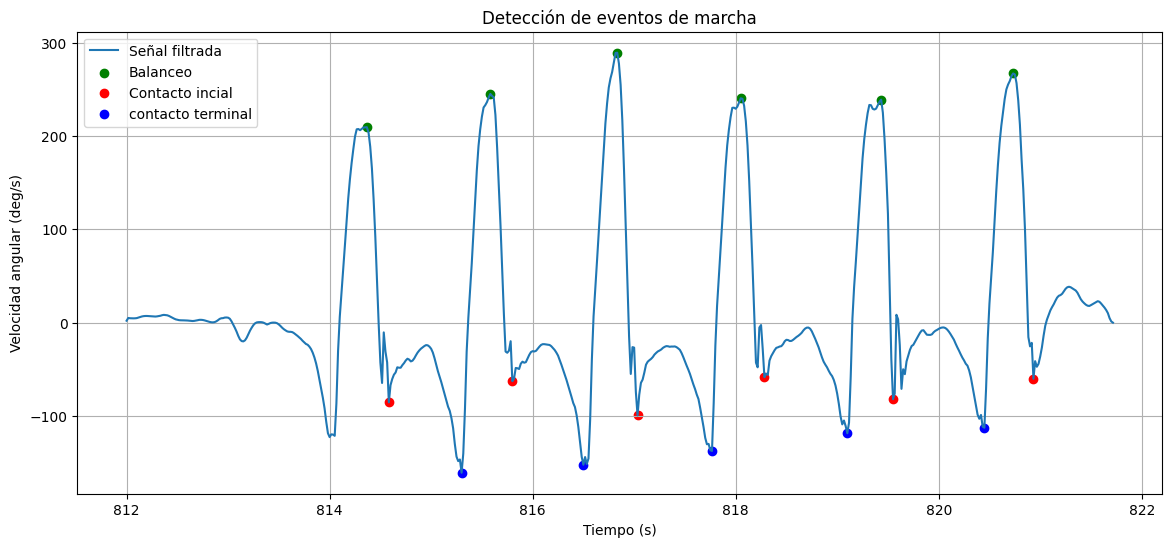

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(tiempo_segundos, senal_velocidad_angular, label='Señal filtrada')

plt.scatter(tiempo_segundos[balanceo_medio], senal_velocidad_angular[balanceo_medio], color='green', label='Balanceo')
plt.scatter(tiempo_segundos[contacto_inicial_pie], senal_velocidad_angular[contacto_inicial_pie], color='red', label='Contacto incial')
plt.scatter(tiempo_segundos[contacto_terminal_pie], senal_velocidad_angular[contacto_terminal_pie], color='blue', label='contacto terminal')

plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad angular (deg/s)')
plt.title('Detección de eventos de marcha')

plt.legend()
plt.grid()
plt.show()

In [ ]:
print(tiempo_segundos[contacto_inicial_pie])

[814.58237  815.799061 817.032419 818.282444 819.549136 820.932497]


In [ ]:
print(tiempo_segundos[contacto_terminal_pie])

[815.299051 816.499075 817.765767 819.099127 820.449154]


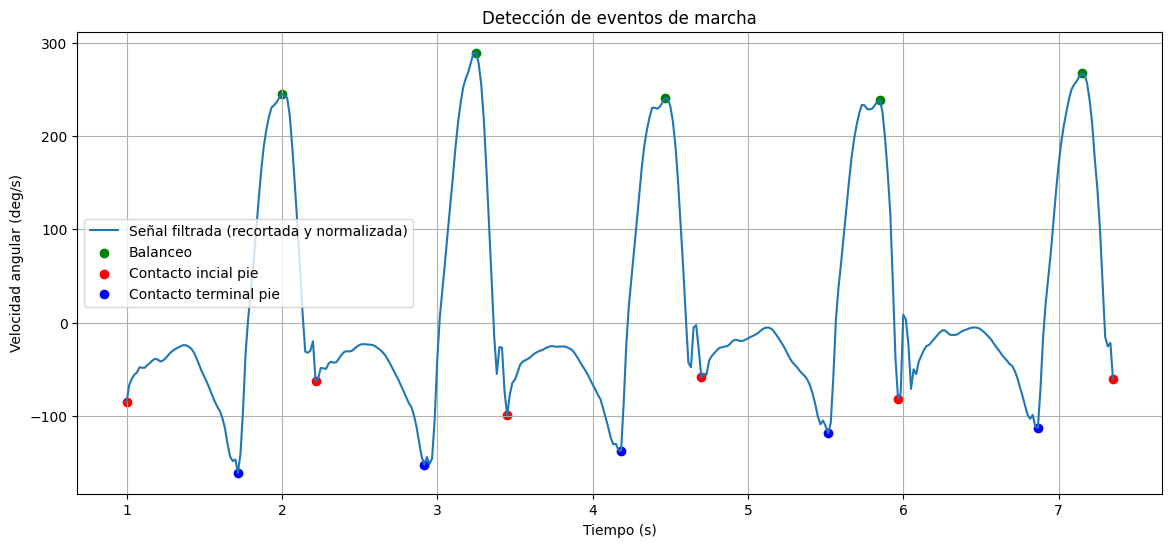

In [ ]:

# Toma el primer y ultimo IC de la señal original
primer_IC = contacto_inicial_pie[0]
ultimo_IC = contacto_inicial_pie[-1]

#Recortar la señal desde el 1er IC hasta el ultimo IC que es lo que nos interesa
tiempo_recortado_segundos = datos_marcha['tiempo_segundos'].values[primer_IC : ultimo_IC + 1]
senal_recortada = senal_velocidad_angular[primer_IC : ultimo_IC + 1]

#Normalizar el tiempo para que inicie en 1 segundo
tiempo_normalizado_segundos = tiempo_recortado_segundos - tiempo_recortado_segundos[0] + 1

#Ajustar el indice de los eventos para que sean relativos al inicio del segmento recortado
indices_balanceo_medio_recortado = [indice - primer_IC for indice in balanceo_medio if primer_IC <= indice <= ultimo_IC]
indices_contacto_inicial_recortados = [indice - primer_IC for indice in contacto_inicial_pie if primer_IC <= indice <= ultimo_IC]
indices_contacto_final_recortados = [indice - primer_IC for indice in contacto_terminal_pie if primer_IC <= indice <= ultimo_IC]

plt.figure(figsize=(14,6))

plt.plot(tiempo_normalizado_segundos, senal_recortada, label='Señal filtrada (recortada y normalizada)')

# Marca los eventos con los indices ya ajustados debido a la normalización del tiempo
plt.scatter(tiempo_normalizado_segundos[indices_balanceo_medio_recortado], senal_recortada[indices_balanceo_medio_recortado], color='green', label='Balanceo')
plt.scatter(tiempo_normalizado_segundos[indices_contacto_inicial_recortados], senal_recortada[indices_contacto_inicial_recortados], color='red', label='Contacto incial pie')
plt.scatter(tiempo_normalizado_segundos[indices_contacto_final_recortados], senal_recortada[indices_contacto_final_recortados], color='blue', label='Contacto terminal pie')

plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad angular (deg/s)')
plt.title('Detección de eventos de marcha')

plt.legend()
plt.grid()
plt.show()

In [ ]:
# Muestra los valores identificados de contacto inicial

print(' Valores de IC en gráfica normalizada')
for i, indice in enumerate(indices_contacto_inicial_recortados):
    print(f'IC {i+1}: Tiempo = {tiempo_normalizado_segundos[indice]:.4f} s, Señal = {senal_recortada[indice]:.4f} deg/s')

#Muestra los valores identificados de inicio de balanceo o despegue del suelo

print('\nValores de TC en gráfica normalizada')
for i, indice in enumerate(indices_contacto_final_recortados):
    print(f'TC {i+1}: Tiempo = {tiempo_normalizado_segundos[indice]:.4f} s, Señal = {senal_recortada[indice]:.4f} deg/s')

 Valores de IC en gráfica normalizada
IC 1: Tiempo = 1.0000 s, Señal = -85.3487 deg/s
IC 2: Tiempo = 2.2167 s, Señal = -62.7237 deg/s
IC 3: Tiempo = 3.4500 s, Señal = -99.3779 deg/s
IC 4: Tiempo = 4.7001 s, Señal = -58.4745 deg/s
IC 5: Tiempo = 5.9668 s, Señal = -82.0054 deg/s
IC 6: Tiempo = 7.3501 s, Señal = -60.1594 deg/s

Valores de TC en gráfica normalizada
TC 1: Tiempo = 1.7167 s, Señal = -160.7482 deg/s
TC 2: Tiempo = 2.9167 s, Señal = -152.1925 deg/s
TC 3: Tiempo = 4.1834 s, Señal = -137.4595 deg/s
TC 4: Tiempo = 5.5168 s, Señal = -118.4748 deg/s
TC 5: Tiempo = 6.8668 s, Señal = -112.5580 deg/s


In [ ]:
print('Duración de los Ciclos de Marcha')

# Obtiene los tiempos de IC de la gráfica normalizada
tiempos_contacto_inicial = [tiempo_normalizado_segundos[indice] for indice in indices_contacto_inicial_recortados]

# Calcula la duración de cada ciclo de marcha
duracion_ciclo = []
for i in range(1, len(tiempos_contacto_inicial)):
    duracion = tiempos_contacto_inicial[i] - tiempos_contacto_inicial[i-1]
    duracion_ciclo.append(duracion)
    print(f'Ciclo {i}: {duracion:.4f} s')

# calcula el promedio de los ciclos
if duracion_ciclo:
    duracion_promedio_ciclo = np.mean(duracion_ciclo)
    print(f'\nDuración promedio del ciclo de marcha: {duracion_promedio_ciclo:.4f} s')

Duración de los Ciclos de Marcha
Ciclo 1: 1.2167 s
Ciclo 2: 1.2334 s
Ciclo 3: 1.2500 s
Ciclo 4: 1.2667 s
Ciclo 5: 1.3834 s

Duración promedio del ciclo de marcha: 1.2700 s


In [ ]:
# Obtiene los tiempos de TC de la gráfica normalizada
tiempo_despegue_pie = [tiempo_normalizado_segundos[indice] for indice in indices_contacto_final_recortados]

print('\nTiempos de Apoyo de los Ciclos de Marcha')

tiempos_apoyo = []
# Asegura que tenemos un número comparable de ICs y TCs para emparejar
numero_ciclos = min(len(tiempos_contacto_inicial), len(tiempo_despegue_pie))

for i in range(numero_ciclos):
    # Asumimos que TC_i y IC_i corresponden al mismo 'evento' de ciclo de interés
    # y TC_i ocurre después de IC_i para un tiempo de apoyo positivo
    if tiempo_despegue_pie[i] > tiempos_contacto_inicial[i]:
        tiempo_apoyo = tiempo_despegue_pie[i] - tiempos_contacto_inicial[i]
        tiempos_apoyo.append(tiempo_apoyo)
        print(f'Tiempo de Apoyo Ciclo {i+1}: {tiempo_apoyo:.4f} s')
    else:
        print(f'Advertencia: TC {i+1} ({tiempo_despegue_pie[i]:.4f} s) no ocurre después de IC {i+1} ({tiempos_contacto_inicial[i]:.4f} s). No se calculó el tiempo de apoyo para este ciclo.')

# Calcula y muestra el promedio de los tiempos de apoyo
if tiempos_apoyo:
    tiempo_promedio_apoyo = np.mean(tiempos_apoyo)
    print(f'\nDuración promedio del tiempo de apoyo: {tiempo_promedio_apoyo:.4f} s')
else:
    print('No se pudieron calcular los tiempos de apoyo válidos.')


Tiempos de Apoyo de los Ciclos de Marcha
Tiempo de Apoyo Ciclo 1: 0.7167 s
Tiempo de Apoyo Ciclo 2: 0.7000 s
Tiempo de Apoyo Ciclo 3: 0.7333 s
Tiempo de Apoyo Ciclo 4: 0.8167 s
Tiempo de Apoyo Ciclo 5: 0.9000 s

Duración promedio del tiempo de apoyo: 0.7733 s


In [ ]:
print('\nTiempos de Balanceo de los Ciclos de Marcha')

tiempos_balanceo = []
# Para el tiempo de balanceo, necesitamos IC_n+1 - TC_n
# Asegura que tenemos suficientes eventos para emparejar
numero_balanceos = min(len(tiempos_contacto_inicial) - 1, len(tiempo_despegue_pie))

for i in range(numero_balanceos):
    # siguiente IC es el IC del siguiente ciclo
    siguiente_IC = tiempos_contacto_inicial[i+1]
    # siguiente TC es el TC del ciclo actual
    siguiente_TC = tiempo_despegue_pie[i]

    if siguiente_IC > siguiente_TC:
        tiempo_balanceo = siguiente_IC - siguiente_TC
        tiempos_balanceo.append(tiempo_balanceo)
        print(f'Tiempo de Balanceo Ciclo {i+1}: {tiempo_balanceo:.4f} s')
    else:
        print(f'Advertencia: IC {i+2} ({siguiente_IC:.4f} s) no ocurre después de TC {i+1} ({siguiente_TC:.4f} s). No se calculó el tiempo de balanceo para este ciclo.')

# Calcula y muestra el promedio de los tiempos de balanceo
if tiempos_balanceo:
    tiempo_promedio_balanceo = np.mean(tiempos_balanceo)
    print(f'\nDuración promedio del tiempo de balanceo: {tiempo_promedio_balanceo:.4f} s')
else:
    print('No se pudieron calcular los tiempos de balanceo válidos.')


Tiempos de Balanceo de los Ciclos de Marcha
Tiempo de Balanceo Ciclo 1: 0.5000 s
Tiempo de Balanceo Ciclo 2: 0.5333 s
Tiempo de Balanceo Ciclo 3: 0.5167 s
Tiempo de Balanceo Ciclo 4: 0.4500 s
Tiempo de Balanceo Ciclo 5: 0.4833 s

Duración promedio del tiempo de balanceo: 0.4967 s


In [ ]:
print('\nCadencia Promedio')

cadencia_promedio = (1 / duracion_promedio_ciclo) * 60 * 2
print(
    f"Duración promedio del ciclo de marcha: {duracion_promedio_ciclo:.4f} s, "
    f"Cadencia promedio = {cadencia_promedio:.2f} pasos/min"
)


Cadencia Promedio
Duración promedio del ciclo de marcha: 1.2700 s, Cadencia promedio = 94.49 pasos/min
